### Compare CH parameters

Explores how the CH parameters used by the SR model relate to each other, across solar cycle phases:
1. **$A_{CH}$ vs $P_{CH}$** — the two quantities that make up the SR-derived formula's acceleration term ($\sqrt{A_{CH60,t-4d} 	imes P_{CH30,t-4d}}$)
2. **$P_{CH}$ at 193 Å vs 211 Å** — how the same brightness parameter compares across the two EUV channels used in this study

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

V0 = 372.1075472  # calibrated slow-wind background speed (see CLAUDE.md / paper)

PHASES = ["rising", "maximum", "declining", "minimum"]

dfs = {}
for phase in PHASES:
    csv_path = os.path.abspath(f"../data/processed/SR_training_{phase}.csv")
    df = pd.read_csv(csv_path, parse_dates=["datetime"])
    dfs[phase.capitalize()] = df.dropna(subset=[
        "A_CH60_193_lag4", "P_CH30_193_lag4", "P_CH30_211_lag4", "speed", "speed_p27",
    ])

# "entire" is not committed to git (206MB, exceeds GitHub's limit) but is the exact
# row-wise union of the four phase files above, so we reconstruct it here instead.
dfs["Entire"] = pd.concat(dfs.values(), ignore_index=True).sort_values("datetime")

PHASE_GRID = [
    ("Rising",    (0, 0)), ("Maximum",   (0, 1)), ("Declining", (0, 2)),
    ("Minimum",   (1, 0)), ("Entire",    (1, 1)),
]


def grid_scatter(x_col, y_col, color_val_fn, xlabel, ylabel, cbar_label,
                 xlim=None, ylim=None, fit_on="Entire"):
    """Shared 2x3 grid (5 phases + spare colorbar column) scatter helper."""
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.25, hspace=0.3)
    cax = fig.add_subplot(gs[:, 3])

    sc = None
    for phase, (i, j) in PHASE_GRID:
        df = dfs[phase]
        x, y = df[x_col].to_numpy(), df[y_col].to_numpy()
        color_val = color_val_fn(df)

        ax = fig.add_subplot(gs[i, j])
        sc = ax.scatter(x, y, c=color_val, cmap="turbo", alpha=0.6, s=6)

        if phase == fit_on:
            m = np.isfinite(x) & np.isfinite(y)
            a, b = np.polyfit(x[m], y[m], 1)
            xx = np.array(xlim if xlim else [x[m].min(), x[m].max()])
            ax.plot(xx, a * xx + b, "k-", linewidth=1.5,
                    label=rf"fit: $y={a:.2f}x+{b:.1f}$")
            ax.legend(loc="upper left", fontsize=9)

        if xlim:
            ax.set_xlim(xlim)
        if ylim:
            ax.set_ylim(ylim)
        ax.set_title(f"{phase} (n={len(df):,})", fontsize=13)
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)

    cbar = fig.colorbar(sc, cax=cax)
    cbar.set_label(cbar_label, fontsize=12)
    return fig

---

#### 1. $A_{CH}$ vs $P_{CH}$ feature space

$A_{CH60,193}^{t-4d}$ vs $P_{CH30,211}^{t-4d}$, colored by the formula's background term $\sqrt{v_{slow} \times v_{t-27d}}$.

These two quantities (with the persistence term) are exactly what the SR-derived formula combines; this shows how they jointly populate feature space across solar cycle phases.

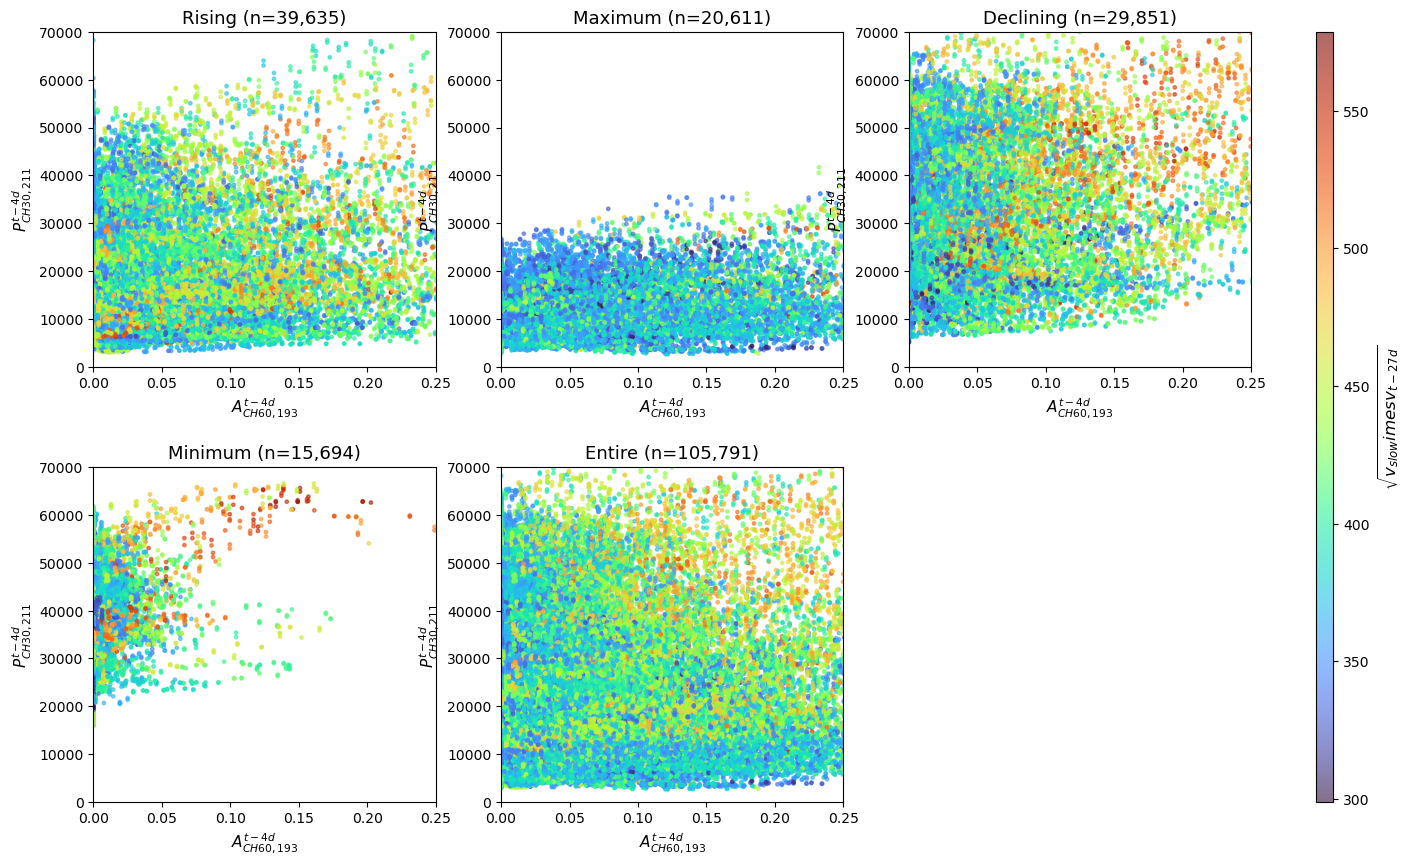

In [2]:
grid_scatter(
    x_col="A_CH60_193_lag4", y_col="P_CH30_211_lag4",
    color_val_fn=lambda df: np.sqrt(V0 * df["speed_p27"].to_numpy()),
    xlabel=r"$A_{CH60,193}^{t-4d}$", ylabel=r"$P_{CH30,211}^{t-4d}$",
    cbar_label=r"$\sqrt{v_{slow} 	imes v_{t-27d}}$",
    xlim=(0, 0.25), ylim=(0, 70000), fit_on=None,
)
plt.show()

---

#### 2. $P_{CH}$ channel relationship: 193 Å vs 211 Å

$P_{CH30,193}^{t-4d}$ vs $P_{CH30,211}^{t-4d}$, colored by solar wind speed, with a linear fit (on the Entire phase) showing how to convert between the two channels.

The SR-derived formula uses $P_{CH30,211}$; this relationship shows what the equivalent $P_{CH30,193}$ value would be, and how tight that relationship is.

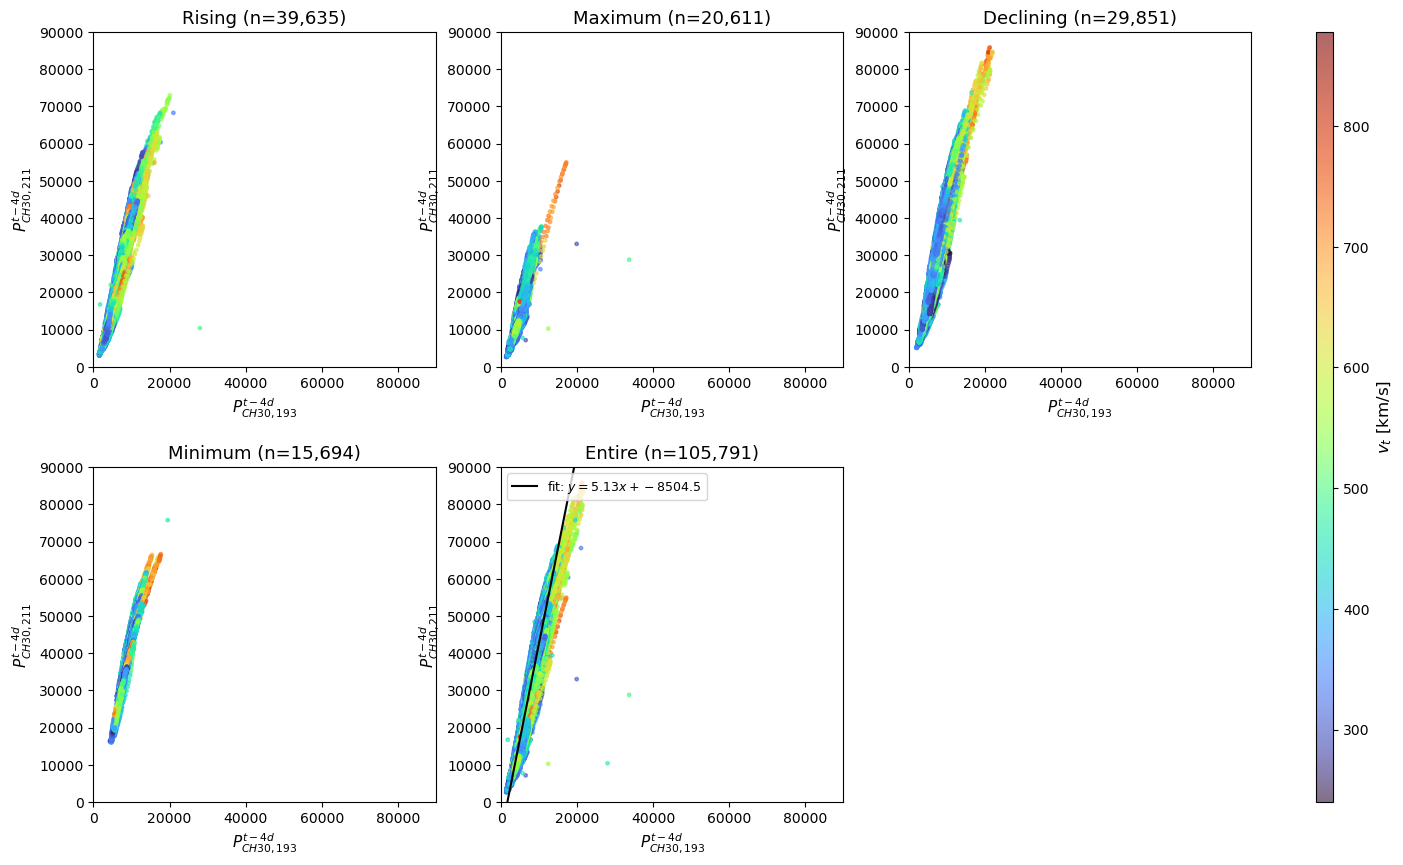

In [3]:
grid_scatter(
    x_col="P_CH30_193_lag4", y_col="P_CH30_211_lag4",
    color_val_fn=lambda df: df["speed"].to_numpy(),
    xlabel=r"$P_{CH30,193}^{t-4d}$", ylabel=r"$P_{CH30,211}^{t-4d}$",
    cbar_label=r"$v_t$ [km/s]",
    xlim=(0, 90000), ylim=(0, 90000), fit_on="Entire",
)
plt.show()